# 1. Depemdances

In [1]:
!python --version

Python 3.12.4


In [2]:
!pip install segmentation-models-pytorch==0.3.3 --quiet
!pip install albumentations==2.0.6 --quiet
!pip install timm --quiet
!pip install "numpy>2" --quiet
!pip install iterative-stratification --quiet
!pip install pandas matplotlib --quiet
!pip install --upgrade pip --quiet

# 2. Imports

In [3]:
import os, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
from tqdm import tqdm

warnings.filterwarnings("ignore")

/Users/admin/Documents/Dev2026/defect-detection-system/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/admin/Documents/Dev2026/defect-detection-system/.venv/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.6'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


# 3. Reproductability Seed

In [4]:
SEED = 42


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = get_device()

print(f"Using device: {DEVICE}")

Using device: mps


# 4 Configuration

In [5]:
CFG = dict(
    # Paths
    TRAIN_CSV="../data/raw/train.csv",
    TRAIN_IMGS="../data/raw/train_images",
    TEST_IMGS="../data/raw/test_images",
    SAMPLE_SUB="../data/raw/sample_submission.csv",
    # Image geometry — keep native width to preserve thin horizontal defects
    IMG_H=256,
    IMG_W=1600,
    # Training hyperparameters
    EPOCHS=50,
    BATCH_SIZE=4,
    LR=3e-4,
    WEIGHT_DECAY=1e-4,
    VAL_SPLIT=0.15,
    NUM_WORKERS=0,
    AMP=True,
    PATIENCE=8,
    # Model
    ENCODER="efficientnet-b4",
    ENCODER_WEIGHTS="imagenet",
    NUM_CLASSES=4,
    # Post-processing thresholds — tuned on validation set in Section 18
    PRED_THRESHOLDS=[0.5, 0.5, 0.5, 0.5],
    MIN_MASK_SIZES=[300, 300, 300, 300],
)

# 5. Class Visualization Function

In [6]:
CLASS_COLORS = ["red", "blue", "green", "orange"]


def denormalize(tensor: torch.Tensor) -> np.ndarray:
    """Convert normalised (3, H, W) tensor → (H, W, 3) uint8 numpy array."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = (tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    return (img * 255).astype(np.uint8)


def visualize_predictions(model, dataset, n_samples=3, thresholds=None):
    """Plot image with ground-truth and predicted masks side-by-side."""
    thresholds = thresholds or CFG["PRED_THRESHOLDS"]
    model.eval()
    indices = random.sample(range(len(dataset)), n_samples)
    fig, axes = plt.subplots(n_samples, 2, figsize=(22, 5 * n_samples))

    for row_idx, ds_idx in enumerate(indices):
        image, gt_mask, _ = dataset[ds_idx]
        with torch.no_grad():
            logits = model(image.unsqueeze(0).to(DEVICE))
        probs = torch.sigmoid(logits).squeeze(0).cpu()

        img_np = denormalize(image)

        for col_idx, (title_suffix, mask_src) in enumerate(
            [
                ("Ground Truth", gt_mask),
                (
                    "Prediction",
                    torch.stack([(probs[c] > thresholds[c]).float() for c in range(4)]),
                ),
            ]
        ):
            ax = axes[row_idx, col_idx]
            ax.imshow(img_np)
            overlay = np.zeros((*img_np.shape[:2], 4), dtype=np.float32)
            for c in range(4):
                m = mask_src[c].numpy().astype(bool)
                if m.any():
                    col = plt.cm.colors.to_rgba(CLASS_COLORS[c], alpha=0.45)
                    overlay[m] = col
            ax.imshow(overlay)
            ax.set_title(
                f"{dataset.df.iloc[ds_idx]['ImageId']} — {title_suffix}", fontsize=10
            )
            ax.axis("off")

    patches = [
        mpatches.Patch(color=c, label=f"Defect {i+1}")
        for i, c in enumerate(CLASS_COLORS)
    ]
    fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=11)
    plt.tight_layout()
    plt.show()

# 6. Data Loading & EDA

In [7]:
df = pd.read_csv(CFG["TRAIN_CSV"])

df["ClassId"] = df["ClassId"].astype(int)
df["has_defect"] = df["EncodedPixels"].notna()

print("── Dataset overview ──────────────────────────────────")
print(f"Total rows:   {len(df)}")
print(f"Unique images:{df['ImageId'].nunique()}")
print("\nDefect distribution per class:")
print(df.groupby("ClassId")["has_defect"].sum().rename("defect_count"))

# Pivot so each row = one image with columns for each class mask
df_pivot = df.pivot(
    index="ImageId", columns="ClassId", values="EncodedPixels"
).reset_index()
df_pivot.columns = ["ImageId", "mask_1", "mask_2", "mask_3", "mask_4"]
df_pivot["n_defect_classes"] = (
    df_pivot[["mask_1", "mask_2", "mask_3", "mask_4"]].notna().sum(axis=1)
)

print("\nImages with 0/1/2/3/4 defect classes:")
print(df_pivot["n_defect_classes"].value_counts().sort_index())

── Dataset overview ──────────────────────────────────
Total rows:   7095
Unique images:6666

Defect distribution per class:
ClassId
1     897
2     247
3    5150
4     801
Name: defect_count, dtype: int64

Images with 0/1/2/3/4 defect classes:
n_defect_classes
1    6239
2     425
3       2
Name: count, dtype: int64


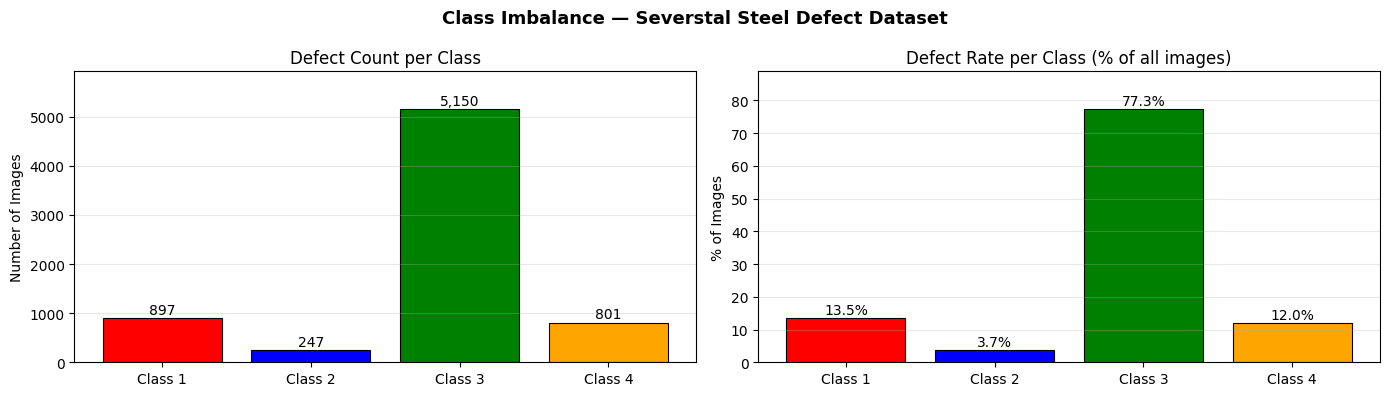

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Defect count per class
class_counts = df.groupby("ClassId")["has_defect"].sum()
bars = axes[0].bar(
    [f"Class {i}" for i in class_counts.index],
    class_counts.values,
    color=CLASS_COLORS,
    edgecolor="black",
    linewidth=0.8,
)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{val:,}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
axes[0].set_title("Defect Count per Class", fontsize=12)
axes[0].set_ylabel("Number of Images")
axes[0].set_ylim(0, class_counts.max() * 1.15)
axes[0].grid(axis="y", alpha=0.3)

# Defect rate per class (as % of total images)
total_images = df["ImageId"].nunique()
defect_rates = class_counts / total_images * 100
axes[1].bar(
    [f"Class {i}" for i in defect_rates.index],
    defect_rates.values,
    color=CLASS_COLORS,
    edgecolor="black",
    linewidth=0.8,
)
for bar, val in zip(axes[1].patches, defect_rates.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )
axes[1].set_title("Defect Rate per Class (% of all images)", fontsize=12)
axes[1].set_ylabel("% of Images")
axes[1].set_ylim(0, defect_rates.max() * 1.15)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle(
    "Class Imbalance — Severstal Steel Defect Dataset", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

# 7 RLE Encoder & Decoder

In [9]:
def rle_decode(mask_rle: str, shape=(256, 1600)) -> np.ndarray:
    """Decode RLE string → binary numpy mask.  Fortran (column-major) order."""
    if not isinstance(mask_rle, str) or mask_rle.strip() == "":
        return np.zeros(shape, dtype=np.uint8)
    s = mask_rle.split()
    starts = np.asarray(s[0::2], dtype=int) - 1
    lengths = np.asarray(s[1::2], dtype=int)
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, ln in zip(starts, lengths):
        img[lo : lo + ln] = 1
    return img.reshape(shape, order="F")


def rle_encode(mask: np.ndarray) -> str:
    """Encode binary mask → RLE string for submission."""
    pixels = mask.flatten(order="F")
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(runs.astype(str))


# Quick sanity check — round-trip should be lossless
_sample_rle = df.loc[df["has_defect"].idxmax(), "EncodedPixels"]
assert rle_encode(rle_decode(_sample_rle)) == _sample_rle, "RLE round-trip failed!"
print("RLE round-trip check passed")

RLE round-trip check passed


# 8. Defect Clases Visiualzation with Sample Images 

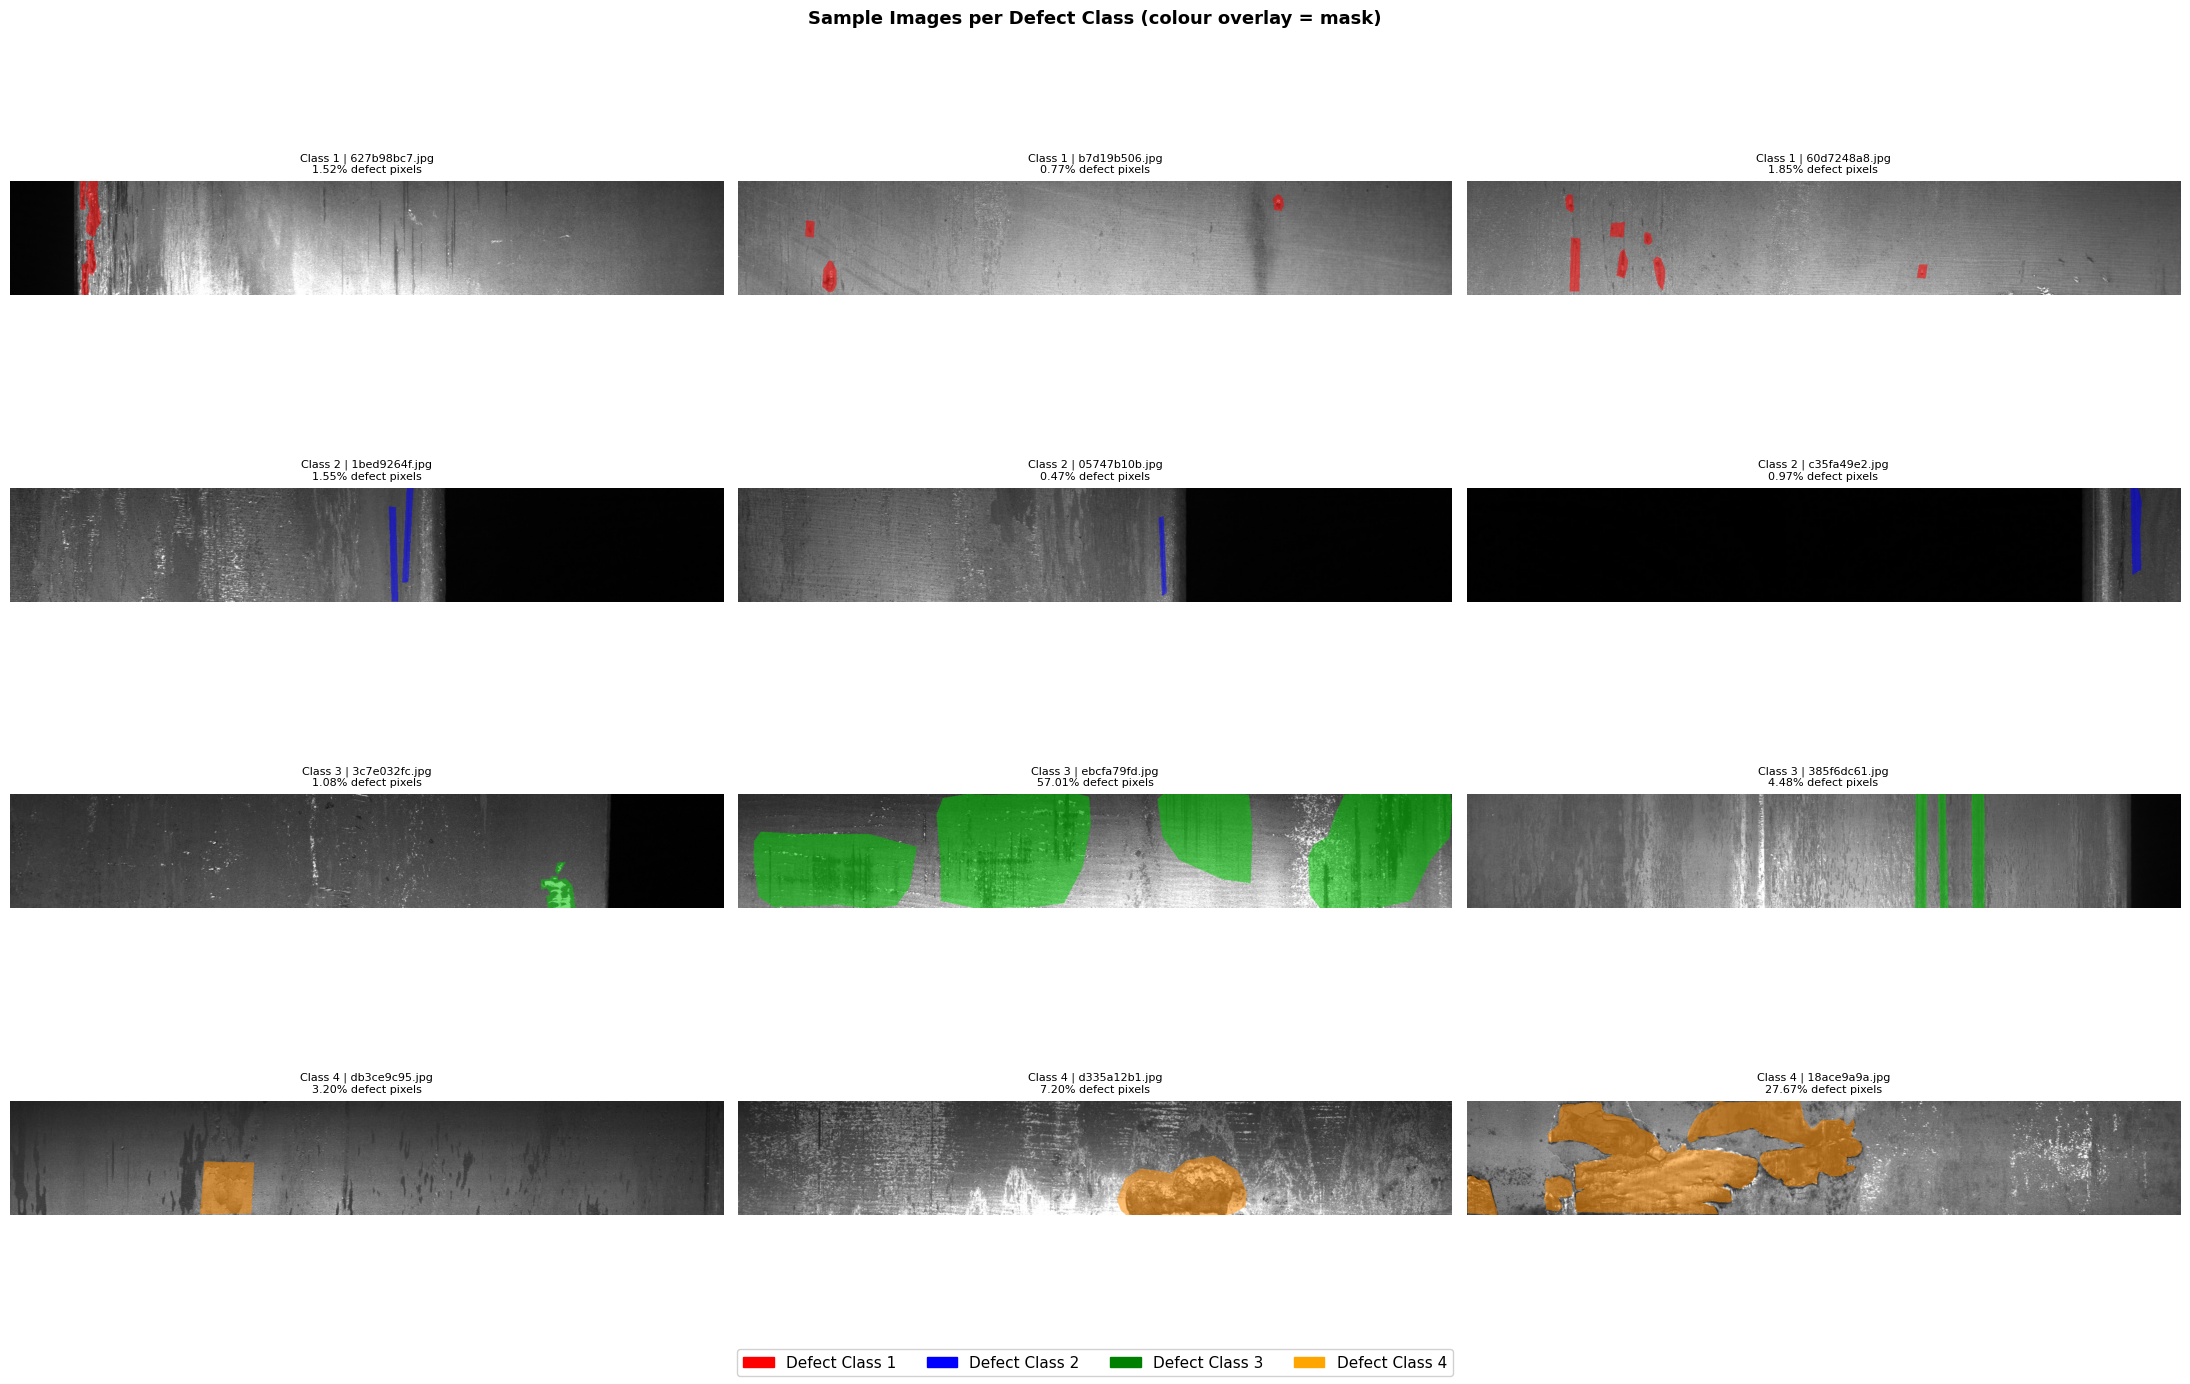

In [10]:
# ── EDA: Sample images per defect class ──────────────────────────────────────
N_SAMPLES = 3  # images per class row

fig, axes = plt.subplots(4, N_SAMPLES, figsize=(22, 14))

for cls_idx, col in enumerate(["mask_1", "mask_2", "mask_3", "mask_4"]):
    # Only rows that actually have a mask for this class
    positives = df_pivot[df_pivot[col].notna()].sample(
        n=min(N_SAMPLES, df_pivot[col].notna().sum()), random_state=SEED
    )

    for sample_idx, (_, row) in enumerate(positives.iterrows()):
        ax = axes[cls_idx, sample_idx]

        img_path = os.path.join(CFG["TRAIN_IMGS"], row["ImageId"])
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]

        mask = rle_decode(row[col], shape=(h, w))

        # Colour overlay
        overlay = image.copy().astype(np.float32)
        color_map = {
            "mask_1": (255, 0, 0),
            "mask_2": (0, 0, 255),
            "mask_3": (0, 200, 0),
            "mask_4": (255, 140, 0),
        }
        rgb = color_map[col]
        for ch, val in enumerate(rgb):
            overlay[:, :, ch] = np.where(
                mask == 1,
                image[:, :, ch] * 0.45 + val * 0.55,
                image[:, :, ch],
            )
        ax.imshow(overlay.astype(np.uint8))

        # Defect pixel ratio as subtitle
        defect_pct = mask.sum() / mask.size * 100
        ax.set_title(
            f"Class {cls_idx+1} | {row['ImageId']}\n{defect_pct:.2f}% defect pixels",
            fontsize=8,
        )
        ax.axis("off")

    # Row label on the left
    axes[cls_idx, 0].set_ylabel(
        f"Class {cls_idx+1}",
        fontsize=11,
        fontweight="bold",
        rotation=0,
        labelpad=55,
        va="center",
    )

patches = [
    mpatches.Patch(color=c, label=f"Defect Class {i+1}")
    for i, c in enumerate(CLASS_COLORS)
]
fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=11, framealpha=0.9)
plt.suptitle(
    "Sample Images per Defect Class (colour overlay = mask)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# 9. Train/Validation Split

In [11]:
# MultilabelStratifiedShuffleSplit — guarantees all 4 classes are proportionally represented in val, not just the binary has_any_defect flag.
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

df_pivot["has_any_defect"] = (df_pivot["n_defect_classes"] > 0).astype(int)

label_matrix = (
    df_pivot[["mask_1", "mask_2", "mask_3", "mask_4"]].notna().astype(int).values
)

msss = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=CFG["VAL_SPLIT"], random_state=SEED
)
train_idx, val_idx = next(msss.split(df_pivot["ImageId"].values, label_matrix))

train_df = df_pivot.iloc[train_idx].reset_index(drop=True)
val_df = df_pivot.iloc[val_idx].reset_index(drop=True)

print(f"Train: {len(train_df)} images | Val: {len(val_df)} images")
print("\nPer-class positive rate in val (all must be non-zero):")
for i, col in enumerate(["mask_1", "mask_2", "mask_3", "mask_4"]):
    rate = val_df[col].notna().mean()
    status = "OK" if rate > 0 else "EMPTY"
    print(f"  Class {i+1}: {rate:.2%}  {status}")

Train: 5658 images | Val: 1008 images

Per-class positive rate in val (all must be non-zero):
  Class 1: 13.39%  OK
  Class 2: 3.67%  OK
  Class 3: 76.69%  OK
  Class 4: 11.90%  OK


# 10. Augmentation Strategy

In [12]:
#    • Train: spatial + photometric augmentations, mask-aligned
#    • Val:   only normalize (no data leakage from augmentation)

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def get_train_transforms(h=CFG["IMG_H"], w=CFG["IMG_W"]):
    return A.Compose(
        [
            A.Resize(h, w),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.0, scale_limit=0.1, rotate_limit=5, p=0.4),
            A.OneOf(
                [
                    A.RandomBrightnessContrast(
                        brightness_limit=0.2, contrast_limit=0.2
                    ),
                    A.HueSaturationValue(
                        hue_shift_limit=5, sat_shift_limit=20, val_shift_limit=20
                    ),
                ],
                p=0.4,
            ),
            # Geometric distortions help generalise to unseen defect shapes.
            # NOTE: alpha_affine removed — deprecated in Albumentations >= 1.3
            A.OneOf(
                [
                    A.ElasticTransform(alpha=80, sigma=80 * 0.05, p=0.3),
                    A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.3),
                ],
                p=0.25,
            ),
            A.CoarseDropout(
                max_holes=8, max_height=16, max_width=16, fill_value=0, p=0.2
            ),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]
    )


def get_val_transforms(h=CFG["IMG_H"], w=CFG["IMG_W"]):
    return A.Compose(
        [
            A.Resize(h, w),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]
    )

# 11. Dataset Creation

In [13]:
class SteelDataset(Dataset):
    """
    Returns:
        image      : FloatTensor (3, H, W)  — normalised
        mask       : FloatTensor (4, H, W)  — one channel per defect class, 0/1
        has_defect : int (0 or 1)           — used by WeightedRandomSampler
    """

    def __init__(self, df: pd.DataFrame, image_dir: str, transforms=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["ImageId"])

        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image not found: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w = image.shape[:2]
        mask = np.zeros((h, w, 4), dtype=np.uint8)  # (H, W, 4)

        for cls_idx, col in enumerate(["mask_1", "mask_2", "mask_3", "mask_4"]):
            rle = row[col]
            if isinstance(rle, str) and rle.strip():
                mask[:, :, cls_idx] = rle_decode(rle, shape=(h, w))

        if self.transforms:
            aug = self.transforms(image=image, mask=mask)
            image = aug["image"]  # (3, H, W) FloatTensor
            # Fix 3: ToTensorV2 outputs mask as (H, W, C) — permute explicitly
            mask = aug["mask"].permute(2, 0, 1).float()  # (4, H, W)

        has_defect = int(mask.sum() > 0)
        return image, mask, has_defect


# ── Fix 3: Dataset shape unit test — run once, catch silent shape bugs ────
_ds = SteelDataset(train_df.head(4), CFG["TRAIN_IMGS"], get_train_transforms())
_img, _mask, _has_defect = _ds[0]

assert _img.shape == (3, CFG["IMG_H"], CFG["IMG_W"]), f"Bad image shape: {_img.shape}"
assert _mask.shape == (4, CFG["IMG_H"], CFG["IMG_W"]), f"Bad mask shape:  {_mask.shape}"
assert _mask.max() <= 1.0 and _mask.min() >= 0.0, "Mask values out of [0,1]"
assert isinstance(_has_defect, int), "has_defect should be int"

print(f"Dataset shapes OK — image: {tuple(_img.shape)}, mask: {tuple(_mask.shape)}")
del _ds, _img, _mask, _has_defect

Dataset shapes OK — image: (3, 256, 1600), mask: (4, 256, 1600)


# 12. Weigthed Sampler

In [14]:
#    Oversamples images that contain defects so the model sees them more often.
def build_weighted_sampler(dataset: SteelDataset) -> WeightedRandomSampler:
    labels = dataset.df["has_any_defect"].values.astype(int)
    class_counts = np.bincount(labels)  # [n_no_defect, n_defect]
    class_weights = 1.0 / class_counts  # inverse frequency
    sample_weights = class_weights[labels]
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).float(),
        num_samples=len(sample_weights),
        replacement=True,
    )
    return sampler

# 13. Combined Loss Function: Dice + BCE

In [15]:
class DiceBCELoss(nn.Module):
    """
    Combined Dice + Binary Cross-Entropy loss.
    Dice handles class imbalance (penalises FP/FN equally).
    BCE stabilises gradient flow in early training.
    """

    def __init__(self, bce_weight: float = 0.5, smooth: float = 1.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def dice_loss(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        batch_size = probs.shape[0]
        probs = probs.view(batch_size, -1)
        targets = targets.view(batch_size, -1)
        intersection = (probs * targets).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (
            probs.sum(dim=1) + targets.sum(dim=1) + self.smooth
        )
        return 1.0 - dice.mean()

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        return self.bce_weight * self.bce(logits, targets) + (
            1 - self.bce_weight
        ) * self.dice_loss(logits, targets)

# 14. Model: U-Net + EfficientNet-B4 encoder

In [16]:
def build_model() -> nn.Module:
    model = smp.Unet(
        encoder_name=CFG["ENCODER"],
        encoder_weights=CFG["ENCODER_WEIGHTS"],
        in_channels=3,
        classes=CFG["NUM_CLASSES"],
        activation=None,
    )
    model = model.to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs")
        model = nn.DataParallel(model)  # splits each batch across both T4s
    return model

# 15. Metrics

In [17]:
def dice_score(pred: torch.Tensor, target: torch.Tensor, smooth: float = 1e-6) -> float:
    """
    Compute mean Dice over the batch.
    pred, target: (N, C, H, W) binary tensors
    """
    pred = pred.view(pred.shape[0], pred.shape[1], -1).float()
    target = target.view(target.shape[0], target.shape[1], -1).float()
    intersection = (pred * target).sum(dim=2)
    # When both pred and target are empty for a class → Dice = 1 (per competition rules)
    dice = torch.where(
        (pred.sum(dim=2) + target.sum(dim=2)) == 0,
        torch.ones_like(intersection),
        (2.0 * intersection + smooth) / (pred.sum(dim=2) + target.sum(dim=2) + smooth),
    )
    return dice.mean().item()

# 16. Training and Validation Loops

In [18]:
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    running_loss = 0.0
    running_dice = 0.0

    for images, masks, _ in tqdm(loader, desc="  train", leave=False):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=CFG["AMP"]):
            logits = model(images)  # (B, 4, H, W)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        # Fix 2: detach after optimizer step — no gradient history, no AMP context
        with torch.no_grad():
            preds = (torch.sigmoid(logits.detach()) > 0.5).float()
            running_dice += dice_score(preds, masks)

        running_loss += loss.item()

    n = len(loader)
    return running_loss / n, running_dice / n


@torch.no_grad()
def val_epoch(model, loader, criterion, thresholds=None):
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    thresholds = thresholds or [0.5] * CFG["NUM_CLASSES"]

    for images, masks, _ in tqdm(loader, desc="  val  ", leave=False):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        with torch.cuda.amp.autocast(enabled=CFG["AMP"]):
            logits = model(images)
            loss = criterion(logits, masks)

        probs = torch.sigmoid(logits)
        preds = torch.stack(
            [(probs[:, c] > thresholds[c]).float() for c in range(CFG["NUM_CLASSES"])],
            dim=1,
        )

        running_loss += loss.item()
        running_dice += dice_score(preds, masks)

    n = len(loader)
    return running_loss / n, running_dice / n

# 17. Main Train Loop

In [19]:
class EarlyStopping:
    def __init__(self, patience: int, min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None

    def step(self, score: float) -> bool:
        """Returns True when training should stop."""
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience

In [20]:
train_dataset = SteelDataset(train_df, CFG["TRAIN_IMGS"], get_train_transforms())
val_dataset = SteelDataset(val_df, CFG["TRAIN_IMGS"], get_val_transforms())

train_sampler = build_weighted_sampler(train_dataset)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG["BATCH_SIZE"],
    sampler=train_sampler,
    num_workers=CFG["NUM_WORKERS"],
    pin_memory=False,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CFG["BATCH_SIZE"],
    shuffle=False,
    num_workers=CFG["NUM_WORKERS"],
    pin_memory=False,
)

model = build_model()
criterion = DiceBCELoss(bce_weight=0.5)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=CFG["LR"], weight_decay=CFG["WEIGHT_DECAY"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

scaler = torch.cuda.amp.GradScaler(enabled=CFG["AMP"])
early_stopper = EarlyStopping(patience=CFG["PATIENCE"])  # Fix 4

history = {"train_loss": [], "val_loss": [], "train_dice": [], "val_dice": []}
best_val_dice = 0.0
CHECKPOINT_PATH = "../models/best_model.pth"
Path(CHECKPOINT_PATH).parent.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print(f"Training for up to {CFG['EPOCHS']} epochs on {DEVICE}")
print("=" * 60)

for epoch in range(1, CFG["EPOCHS"] + 1):
    tr_loss, tr_dice = train_epoch(model, train_loader, optimizer, criterion, scaler)
    vl_loss, vl_dice = val_epoch(model, val_loader, criterion, CFG["PRED_THRESHOLDS"])
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_dice"].append(tr_dice)
    history["val_dice"].append(vl_dice)

    improved = "  ← best" if vl_dice > best_val_dice else ""
    print(
        f"Epoch [{epoch:3d}/{CFG['EPOCHS']}] "
        f"| train_loss {tr_loss:.4f}  train_dice {tr_dice:.4f} "
        f"| val_loss {vl_loss:.4f}  val_dice {vl_dice:.4f}"
        f"{improved}"
    )

    if vl_dice > best_val_dice:
        best_val_dice = vl_dice
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_dice": best_val_dice,
                "cfg": CFG,
            },
            CHECKPOINT_PATH,
        )

    # Fix 4: early stopping check
    if early_stopper.step(vl_dice):
        print(
            f"\n⏹ Early stopping at epoch {epoch} (no improvement for {CFG['PATIENCE']} epochs)"
        )
        break

print(f"\nTraining complete. Best val Dice: {best_val_dice:.4f}")

Training for up to 50 epochs on mps


KeyboardInterrupt: 

# 18.  Learning Curves

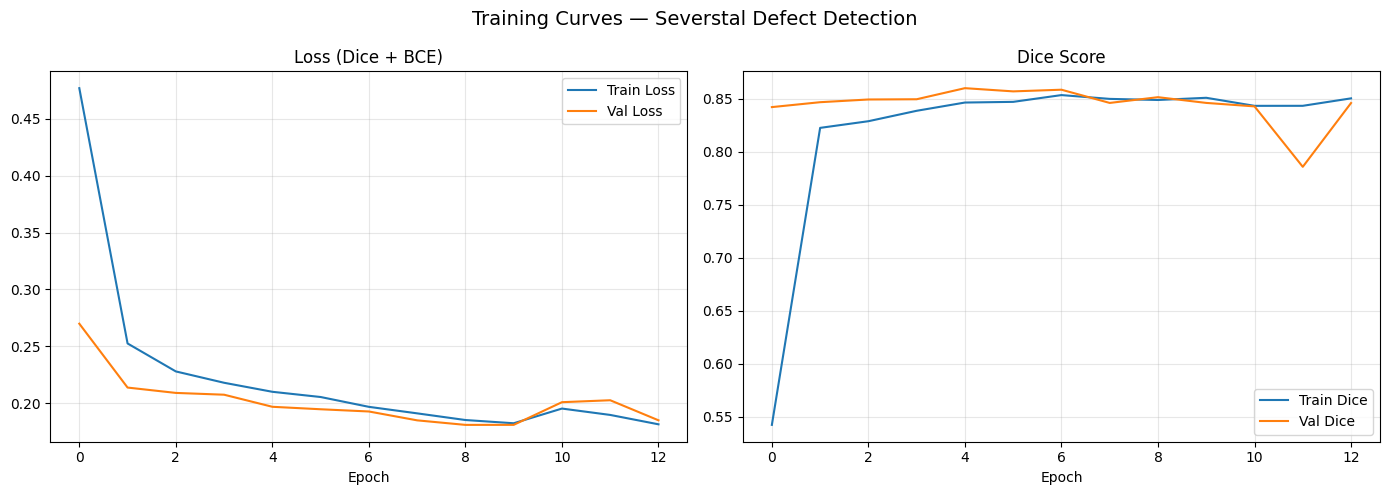

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss (Dice + BCE)")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_dice"], label="Train Dice")
axes[1].plot(history["val_dice"], label="Val Dice")
axes[1].set_title("Dice Score")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Training Curves — Severstal Defect Detection", fontsize=14)
plt.tight_layout()
plt.show()

# 19. Visual Inspection

Loaded best model from epoch 5 (val_dice=0.8601)


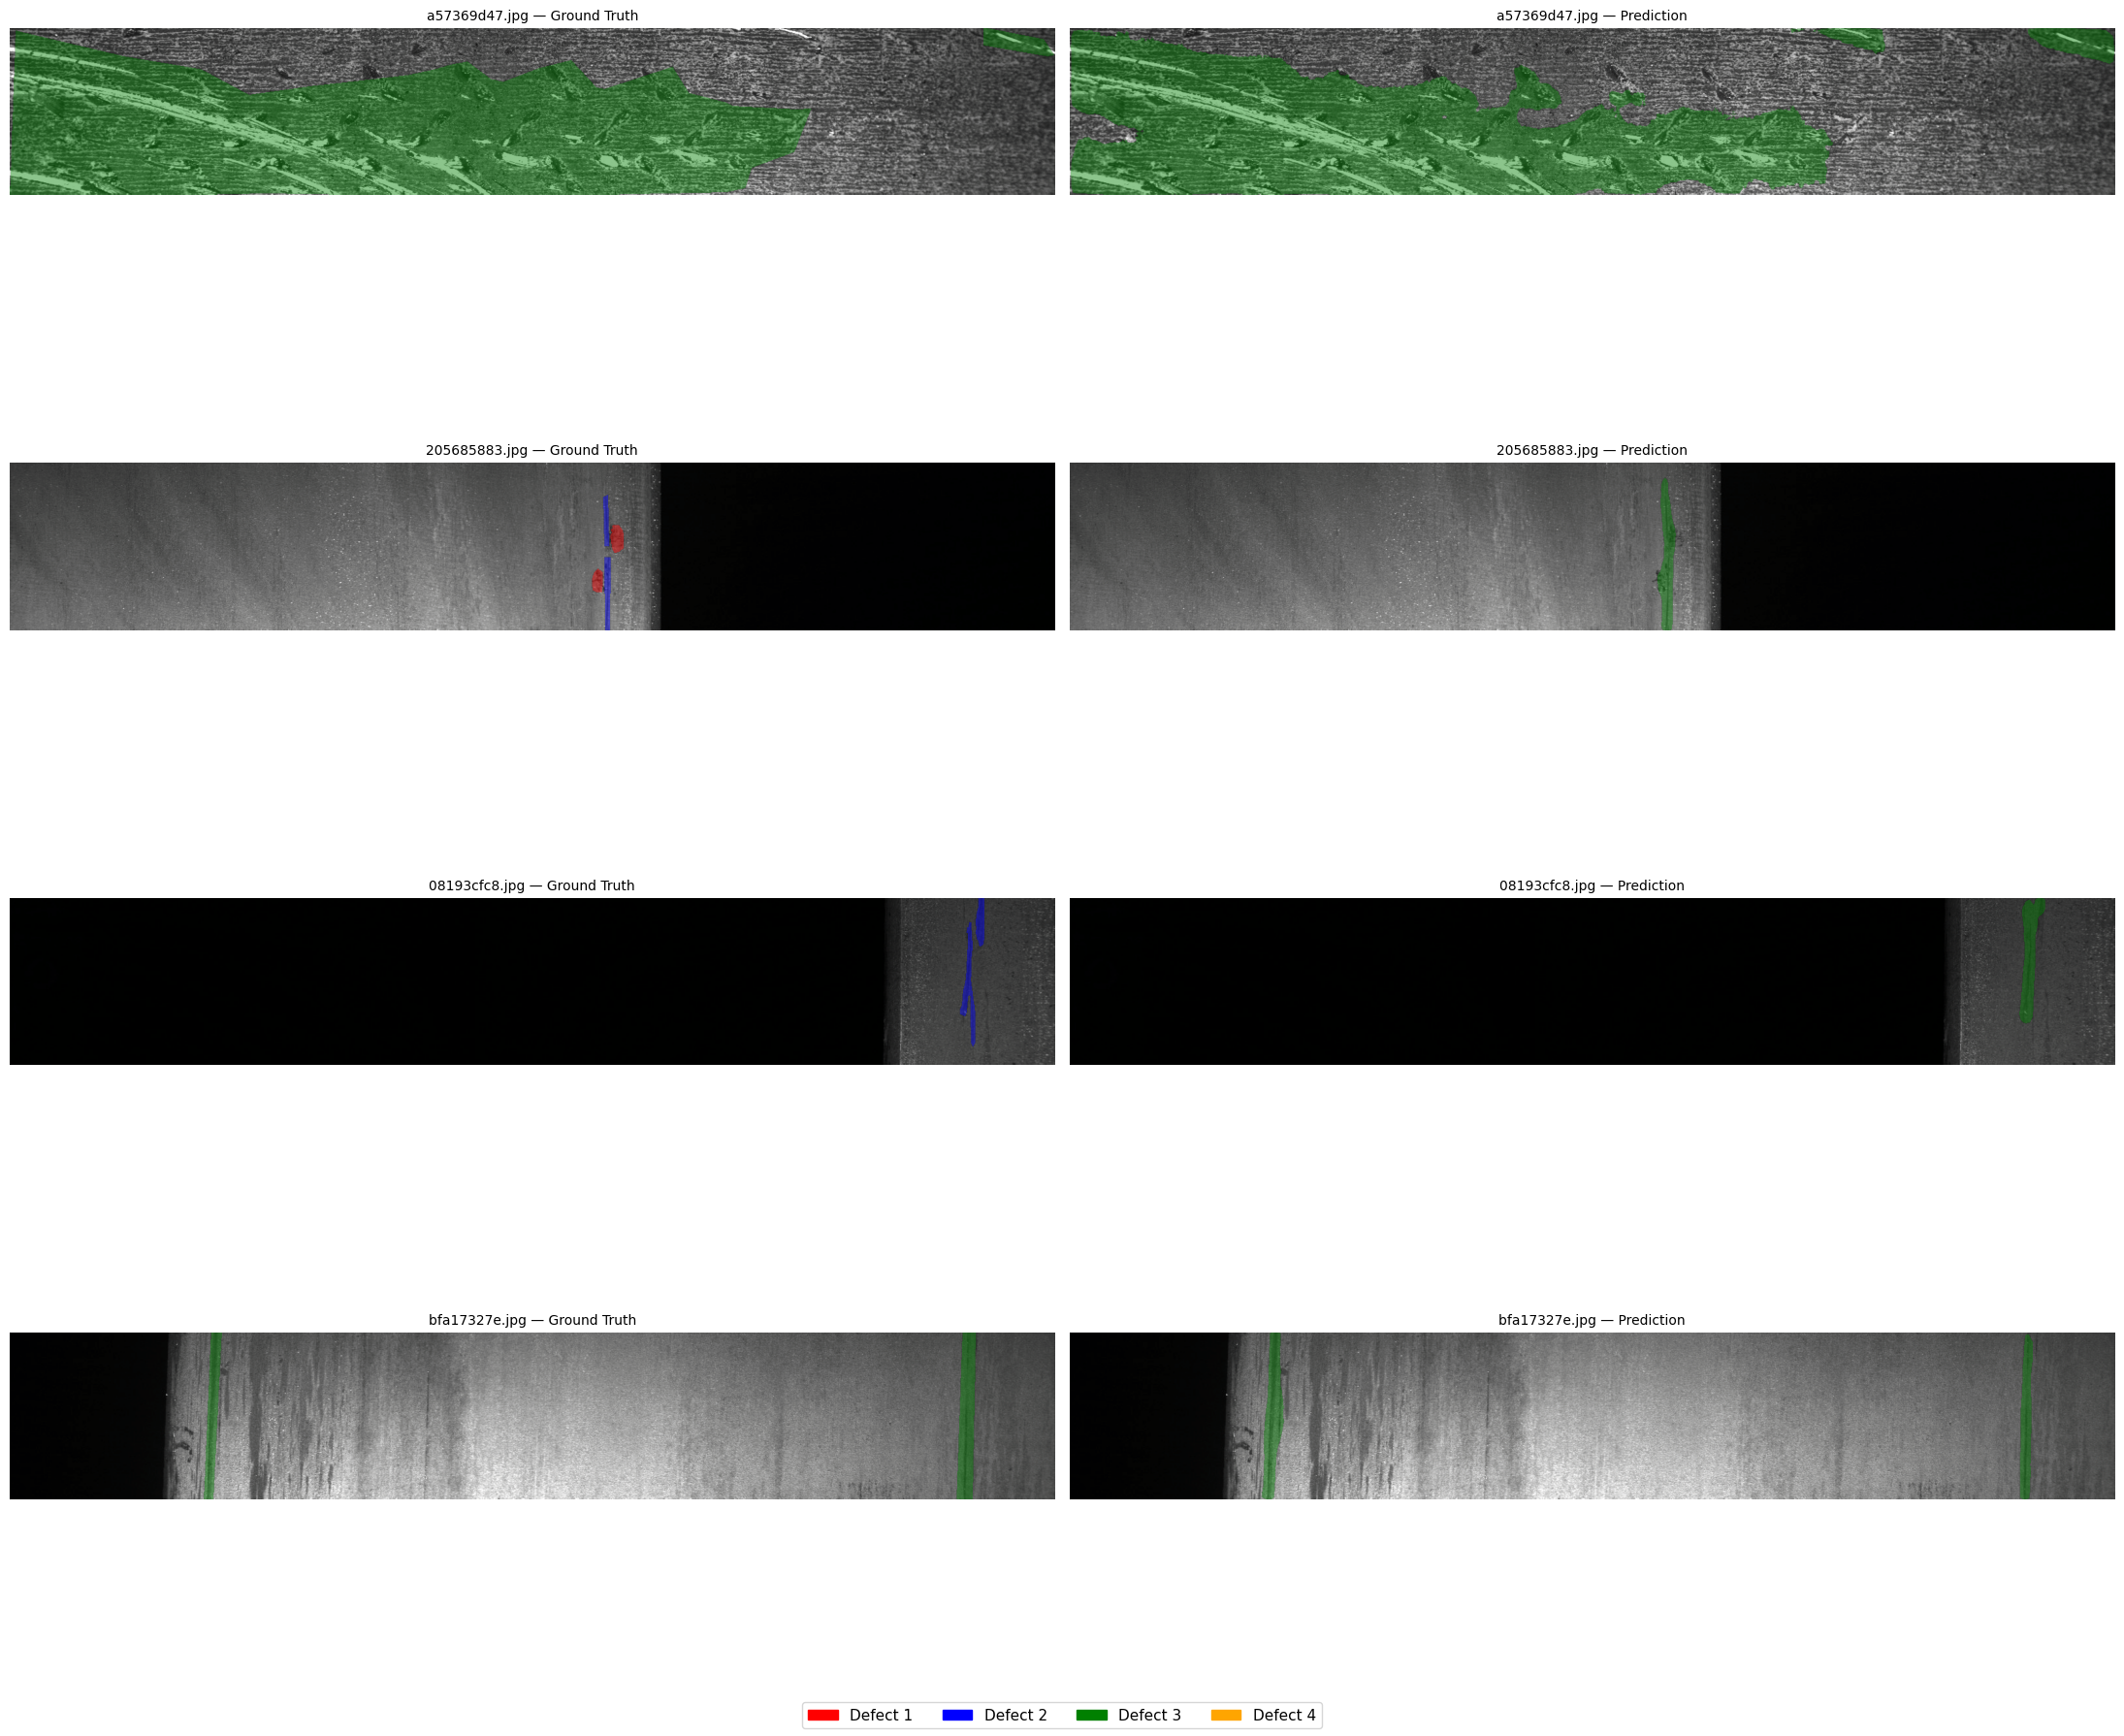

In [ ]:
# Load best weights before visualising
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
print(
    f"Loaded best model from epoch {checkpoint['epoch']} (val_dice={checkpoint['val_dice']:.4f})"
)

visualize_predictions(model, val_dataset, n_samples=4)

# 20. Threshold tuning

In [ ]:
def post_process_mask(mask: np.ndarray, min_size: int) -> np.ndarray:
    """Remove connected components smaller than min_size pixels."""
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask, connectivity=8
    )
    cleaned = np.zeros_like(mask)
    for label_idx in range(1, num_labels):  # 0 = background
        if stats[label_idx, cv2.CC_STAT_AREA] >= min_size:
            cleaned[labels == label_idx] = 1
    return cleaned


# Tune thresholds and min mask sizes independently per class.


@torch.no_grad()
def collect_val_probs(model, loader):
    """Collect all probability maps and ground-truth masks from the val set."""
    all_probs, all_masks = [], []
    model.eval()
    for images, masks, _ in tqdm(loader, desc="Collecting probs"):
        images = images.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=CFG["AMP"]):
            logits = model(images)
        all_probs.append(torch.sigmoid(logits).cpu())
        all_masks.append(masks.cpu())
    return torch.cat(all_probs), torch.cat(all_masks)


def tune_thresholds(
    probs: torch.Tensor, masks: torch.Tensor, candidates=np.arange(0.3, 0.8, 0.05)
):
    best_thresholds = []
    print("\nThreshold tuning per class:")
    for c in range(CFG["NUM_CLASSES"]):
        best_t, best_d = 0.5, 0.0
        for t in candidates:
            preds = (probs[:, c] > t).float()
            d = dice_score(preds.unsqueeze(1), masks[:, c].unsqueeze(1))
            if d > best_d:
                best_d, best_t = d, t
        best_thresholds.append(float(best_t))
        print(f"  Class {c+1}: threshold={best_t:.2f}  dice={best_d:.4f}")
    return best_thresholds


def tune_min_sizes(
    probs: torch.Tensor,
    masks: torch.Tensor,
    thresholds: list,
    candidates=(0, 100, 300, 500, 1000, 2000),
) -> list:
    """Grid search min component size per class on the val set."""
    best_sizes = []
    print("\nMin mask size tuning per class:")
    for c in range(CFG["NUM_CLASSES"]):
        best_size, best_d = 0, 0.0
        for min_size in candidates:
            cleaned_preds = []
            for i in range(len(probs)):
                prob_map = probs[i, c].numpy()
                binary = (prob_map > thresholds[c]).astype(np.uint8)
                binary = post_process_mask(binary, min_size)
                cleaned_preds.append(torch.from_numpy(binary))
            preds_t = torch.stack(cleaned_preds).unsqueeze(1).float()
            d = dice_score(preds_t, masks[:, c].unsqueeze(1))
            if d > best_d:
                best_d, best_size = d, min_size
        best_sizes.append(best_size)
        print(f"  Class {c+1}: min_size={best_size}  dice={best_d:.4f}")
    return best_sizes


val_probs, val_masks = collect_val_probs(model, val_loader)
tuned_thresholds = tune_thresholds(val_probs, val_masks)
tuned_min_sizes = tune_min_sizes(val_probs, val_masks, tuned_thresholds)  # Fix 5
print(f"\nTuned thresholds: {tuned_thresholds}")
print(f"Tuned min sizes:  {tuned_min_sizes}")


Threshold tuning per class:
  Class 1: threshold=0.30  dice=0.8661
  Class 2: threshold=0.30  dice=0.9633
  Class 3: threshold=0.75  dice=0.6539
  Class 4: threshold=0.75  dice=0.9603

Min mask size tuning per class:
  Class 1: min_size=0  dice=0.8661
  Class 2: min_size=0  dice=0.9633
  Class 3: min_size=2000  dice=0.7006
  Class 4: min_size=2000  dice=0.9630

Tuned thresholds: [0.3, 0.3, 0.7499999999999999, 0.7499999999999999]
Tuned min sizes:  [0, 0, 2000, 2000]


# 21. Submition Creation

In [ ]:
def post_process_mask(mask: np.ndarray, min_size: int) -> np.ndarray:
    """Remove connected components smaller than min_size pixels."""
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask, connectivity=8
    )
    cleaned = np.zeros_like(mask)
    for label_idx in range(1, num_labels):  # 0 = background
        if stats[label_idx, cv2.CC_STAT_AREA] >= min_size:
            cleaned[labels == label_idx] = 1
    return cleaned


# Fix 6: Replace image-by-image loop with batched TestDataset + DataLoader (~8x faster)
class TestDataset(Dataset):
    def __init__(self, image_ids, image_dir, transforms):
        self.image_ids = image_ids
        self.image_dir = image_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = os.path.join(self.image_dir, img_id)
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        orig_h, orig_w = image.shape[:2]
        aug = self.transforms(image=image)
        return aug["image"], img_id, orig_h, orig_w


test_df = pd.read_csv(CFG["SAMPLE_SUB"])
test_ids = test_df["ImageId"].unique()

test_dataset = TestDataset(test_ids, CFG["TEST_IMGS"], get_val_transforms())
test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=CFG["NUM_WORKERS"],
    pin_memory=False,
)

model.eval()
submission_rows = []
print(f"\nGenerating predictions for {len(test_ids)} test images...")

for tensors, img_ids, orig_hs, orig_ws in tqdm(test_loader, desc="Inference"):
    tensors = tensors.to(DEVICE)
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=CFG["AMP"]):
        logits = model(tensors)
    probs = torch.sigmoid(logits).cpu().numpy()  # (B, 4, H, W)

    for b, img_id in enumerate(img_ids):
        oh, ow = orig_hs[b].item(), orig_ws[b].item()
        for c in range(4):
            prob_map = cv2.resize(probs[b, c], (ow, oh), interpolation=cv2.INTER_LINEAR)
            binary = (prob_map > tuned_thresholds[c]).astype(np.uint8)
            binary = post_process_mask(binary, tuned_min_sizes[c])  # Fix 5 used here
            rle = rle_encode(binary) if binary.sum() > 0 else ""
            submission_rows.append(
                {"ImageId": img_id, "ClassId": c + 1, "EncodedPixels": rle}
            )

submission = pd.DataFrame(submission_rows)
submission.to_csv("/kaggle/working/submission.csv", index=False)

print("\nsubmission.csv saved!")
print(submission.head(8))
print(
    f"\nRows with predicted defects: {(submission['EncodedPixels'] != '').sum()} / {len(submission)}"
)


Generating predictions for 5506 test images...


Inference: 100%|██████████| 689/689 [04:08<00:00,  2.78it/s]



✅ submission.csv saved!
         ImageId  ClassId                                      EncodedPixels
0  0000f269f.jpg        1                                                   
1  0000f269f.jpg        2                                                   
2  0000f269f.jpg        3  145916 2 146088 10 146104 9 146139 7 146147 2 ...
3  0000f269f.jpg        4                                                   
4  000ccc2ac.jpg        1                                                   
5  000ccc2ac.jpg        2                                                   
6  000ccc2ac.jpg        3  369754 8 370008 12 370260 18 370511 24 370761 ...
7  000ccc2ac.jpg        4                                                   

Rows with predicted defects: 4320 / 22024
